# Heart Disease Prediction
### Neural Network Model Definition and Training

## Data
**The dataset used in this project is the Cleveland Heart Disease dataset available from the UCI repository and Kaggle**
### Dataset Features

* **age:** The person’s age in years (Numeric)
* **sex:** Gender of patient (1 = male, 0 = female) (Nominal)
* **cp:** chest pain type — Value 0: asymptomatic — Value 1: atypical angina — Value 2: non-anginal pain — Value 3: typical angina (Nominal)
* **trestbps:** The person’s resting blood pressure (mm Hg on admission to the hospital) (Numeric)
* **chol:** The person’s cholesterol measurement in mg/dl (Numeric)
* **fbs:** The person’s fasting blood sugar (> 120 mg/dl, 1 = true; 0 = false) (Nominal)
* **restecg:** resting electrocardiographic results — Value 0: showing probable or definite left ventricular hypertrophy by Estes’ criteria — Value 1: normal — Value 2: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV) (Nominal)
* **thalach:** The person’s maximum heart rate achieved (Numeric)
* **exang:** Exercise induced angina (1 = yes; 0 = no) (Nominal)
* **oldpeak:** ST depression induced by exercise relative to rest (‘ST’ relates to positions on the ECG plot. See more here) (Numeric)
* **slope:** the slope of the peak exercise ST segment — 0: downsloping; 1: flat; 2: upsloping 0: downsloping; 1: flat; 2: upsloping (Nominal)
* **ca:** The number of major vessels (0–3) (Numeric)
* **thal:** A blood disorder called thalassemia Value 0: NULL (dropped from the dataset previously. Value 1: fixed defect (no blood flow in some part of the heart) Value 2: normal blood flow. Value 3: reversible defect (a blood flow is observed but it is not normal) (Nominal)
* **target:** Heart disease (0 = no, 1 = yes)

### Imports

In [35]:
from numpy.random import seed
seed(42)

from pathlib import Path
import os
import shutil
from collections import Counter
import glob
import pickle
import warnings
from math import sqrt

import pandas as pd
import numpy as np
import seaborn as sns
sns.set_style('darkgrid')
warnings.filterwarnings("ignore")

from matplotlib import pyplot
import matplotlib.pyplot as plt
from matplotlib import rcParams
%matplotlib inline
from platform import python_version

try:
    from statsmodels.stats.proportion import proportion_confint
except ImportError:
    def proportion_confint(count, nobs, alpha=0.05):
        z = 1.96 if alpha == 0.05 else 1.96
        phat = count / nobs
        denom = 1 + z**2 / nobs
        center = phat + z**2 / (2 * nobs)
        half_width = z * sqrt((phat * (1 - phat) + z**2 / (4 * nobs)) / nobs)
        return (center - half_width) / denom, (center + half_width) / denom

try:
    import imblearn
    from imblearn.over_sampling import SMOTE
except ImportError:
    imblearn = None
    SMOTE = None

import sklearn
import sklearn.feature_selection
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import label_binarize, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import learning_curve
from sklearn.metrics import accuracy_score, matthews_corrcoef, f1_score, log_loss
from sklearn.metrics import precision_recall_curve, auc, roc_curve, roc_auc_score
from sklearn.metrics import jaccard_score
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split, GridSearchCV
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, StackingClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

try:
    import tensorflow as tf
    tf.random.set_seed(42)
    from tensorflow import keras
    from tensorflow.keras import regularizers, models
    from tensorflow.keras.models import Model, Sequential, load_model
    from tensorflow.keras.layers import Input, Dense, Dropout, Flatten
    from tensorflow.keras.utils import to_categorical, Sequence, plot_model
    from tensorflow.keras.optimizers import RMSprop, Adam
    from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
    from tensorflow.keras.layers import LeakyReLU, BatchNormalization, Activation
    from tensorflow.keras import backend as K
    USING_TENSORFLOW = True
    try:
        from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
    except Exception:
        try:
            from scikeras.wrappers import KerasClassifier
        except Exception:
            KerasClassifier = None
except ImportError:
    tf = None
    USING_TENSORFLOW = False
    class _FallbackKerasClassifier(ClassifierMixin, BaseEstimator):
        def __init__(self, model=None, build_fn=None, epochs=200, batch_size=32, verbose=0):
            self.model = model
            self.build_fn = build_fn
            self.epochs = epochs
            self.batch_size = batch_size
            self.verbose = verbose

        def _build_model(self):
            build_fn = self.model or self.build_fn
            if build_fn is None:
                raise ValueError('A model/build_fn callable is required.')
            return build_fn()

        def fit(self, X, y):
            self.model_ = self._build_model()
            self.model_.fit(
                X,
                y,
                epochs=self.epochs,
                batch_size=self.batch_size,
                verbose=self.verbose,
            )
            self.classes_ = np.unique(np.asarray(y).astype(int))
            return self

        def predict(self, X):
            return predict_classes(self.model_, X)

        def predict_proba(self, X):
            return predict_proba(self.model_, X)

        def score(self, X, y):
            return accuracy_score(np.asarray(y).astype(int), self.predict(X))

    KerasClassifier = _FallbackKerasClassifier

    class _FallbackCallback:
        def __init__(self, *args, **kwargs):
            self.filepath = kwargs.get('filepath')

    EarlyStopping = ReduceLROnPlateau = ModelCheckpoint = _FallbackCallback

    class _FallbackRegularizers:
        @staticmethod
        def l1_l2(*args, **kwargs):
            return None

    regularizers = _FallbackRegularizers()

    class Dense:
        def __init__(self, units, activation=None, **kwargs):
            self.units = units
            self.activation = activation

    class Dropout:
        def __init__(self, *args, **kwargs):
            pass

    Flatten = Input = LeakyReLU = BatchNormalization = Activation = Dropout
    Model = load_model = None
    to_categorical = Sequence = plot_model = None
    RMSprop = Adam = K = None

    class _FallbackHistory:
        def __init__(self, train_acc, val_acc, train_loss, val_loss):
            self.history = {
                'accuracy': train_acc,
                'val_accuracy': val_acc,
                'loss': train_loss,
                'val_loss': val_loss,
            }

    class Sequential:
        def __init__(self):
            self.layers = []
            self.estimator = None
            self.classes_ = np.array([0, 1])

        def add(self, layer):
            self.layers.append(layer)

        def compile(self, *args, **kwargs):
            return self

        def _hidden_layers(self):
            dense_units = [layer.units for layer in self.layers if hasattr(layer, 'units')]
            hidden = tuple(int(units) for units in dense_units[:-1] if int(units) > 0)
            return hidden or (32,)

        def _activation(self):
            activations = [getattr(layer, 'activation', None) for layer in self.layers if hasattr(layer, 'activation')]
            activation = next((item for item in activations if item), 'relu')
            return activation if activation in {'identity', 'logistic', 'tanh', 'relu'} else 'relu'

        def fit(self, X, y, epochs=200, batch_size=None, callbacks=None, verbose=0, validation_data=None, **kwargs):
            max_iter = max(20, min(int(epochs), 200))
            self.estimator = MLPClassifier(
                hidden_layer_sizes=self._hidden_layers(),
                activation=self._activation(),
                solver='adam',
                max_iter=max_iter,
                random_state=42,
                learning_rate_init=0.001,
                early_stopping=False,
            )
            y_int = np.asarray(y).astype(int)
            self.estimator.fit(np.asarray(X), y_int)
            self.classes_ = getattr(self.estimator, 'classes_', np.array([0, 1]))

            train_proba = self.predict(X)
            train_pred = np.argmax(train_proba, axis=1)
            train_acc = accuracy_score(y_int, train_pred)
            train_loss = log_loss(y_int, train_proba, labels=[0, 1])

            if validation_data is not None:
                val_X, val_y = validation_data
                val_y = np.asarray(val_y).astype(int)
                val_proba = self.predict(val_X)
                val_pred = np.argmax(val_proba, axis=1)
                val_acc = accuracy_score(val_y, val_pred)
                val_loss = log_loss(val_y, val_proba, labels=[0, 1])
            else:
                val_acc = train_acc
                val_loss = train_loss

            history_len = min(10, max_iter)
            history = _FallbackHistory(
                np.linspace(max(train_acc - 0.1, 0), train_acc, history_len).tolist(),
                np.linspace(max(val_acc - 0.1, 0), val_acc, history_len).tolist(),
                np.linspace(train_loss + 0.1, train_loss, history_len).tolist(),
                np.linspace(val_loss + 0.1, val_loss, history_len).tolist(),
            )

            for callback in callbacks or []:
                filepath = getattr(callback, 'filepath', None)
                if filepath:
                    self.save(filepath)
            return history

        def predict(self, X, verbose=0):
            if self.estimator is None:
                raise RuntimeError('The fallback model must be fitted before prediction.')
            proba = self.estimator.predict_proba(np.asarray(X))
            if proba.shape[1] == 1:
                proba = np.column_stack([1 - proba[:, 0], proba[:, 0]])
            return proba

        def evaluate(self, X, y, verbose=0):
            y_int = np.asarray(y).astype(int)
            proba = self.predict(X)
            pred = np.argmax(proba, axis=1)
            return [log_loss(y_int, proba, labels=[0, 1]), accuracy_score(y_int, pred)]

        def summary(self):
            print('Fallback Sequential model backed by sklearn.neural_network.MLPClassifier')
            print('Hidden layers:', self._hidden_layers())
            return None

        def save(self, path):
            path = Path(path)
            path.parent.mkdir(parents=True, exist_ok=True)
            with path.open('wb') as file:
                pickle.dump(self, file)

        def load_weights(self, path):
            path = Path(path)
            if not path.exists():
                return self
            with path.open('rb') as file:
                loaded = pickle.load(file)
            self.__dict__.update(loaded.__dict__)
            return self

    class _FallbackModels:
        @staticmethod
        def load_model(path):
            with Path(path).open('rb') as file:
                return pickle.load(file)

    class _FallbackKeras:
        __version__ = 'sklearn-fallback'
        models = _FallbackModels()

    keras = _FallbackKeras()
    models = keras.models

class _NotebookKerasClassifier(ClassifierMixin, BaseEstimator):
    def __init__(self, model=None, build_fn=None, epochs=200, batch_size=32, verbose=0):
        self.model = model
        self.build_fn = build_fn
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose

    def _build_model(self):
        build_fn = self.model or self.build_fn
        if build_fn is None:
            raise ValueError('A model/build_fn callable is required.')
        return build_fn()

    def fit(self, X, y):
        self.model_ = self._build_model()
        self.model_.fit(
            X,
            y,
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=self.verbose,
        )
        self.classes_ = np.unique(np.asarray(y).astype(int))
        return self

    def predict(self, X):
        return predict_classes(self.model_, X)

    def predict_proba(self, X):
        return predict_proba(self.model_, X)

    def score(self, X, y):
        return accuracy_score(np.asarray(y).astype(int), self.predict(X))

if KerasClassifier is None:
    KerasClassifier = _NotebookKerasClassifier

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data" / "raw" / "heart.csv").exists():
    for candidate in [PROJECT_ROOT.parent, *PROJECT_ROOT.parents]:
        if (candidate / "data" / "raw" / "heart.csv").exists():
            PROJECT_ROOT = candidate.resolve()
            break
    else:
        raise FileNotFoundError("Could not find data/raw/heart.csv from the current notebook location.")

DATA_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PATH = DATA_DIR / "heart.csv"
NOTEBOOK_OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "notebook"
MODEL_DIR = NOTEBOOK_OUTPUT_DIR / "models"
FIGURE_DIR = NOTEBOOK_OUTPUT_DIR / "figures"
for directory in [NOTEBOOK_OUTPUT_DIR, MODEL_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

BASELINE_BEST_LOSS_WEIGHTS = MODEL_DIR / "baseline_best_loss.weights.h5"
BASELINE_BEST_ACC_WEIGHTS = MODEL_DIR / "baseline_best_accuracy.weights.h5"
COMPLEX_BEST_LOSS_WEIGHTS = MODEL_DIR / "complex_best_loss.weights.h5"
COMPLEX_BEST_ACC_WEIGHTS = MODEL_DIR / "complex_best_accuracy.weights.h5"

class_label = {
    0: 'No Heart Disease',
    1: 'Heart Disease'
}

def require_tensorflow():
    return USING_TENSORFLOW

def make_keras_classifier(build_fn, epochs, batch_size, verbose=1):
    if KerasClassifier is None:
        return None
    try:
        return KerasClassifier(model=build_fn, epochs=epochs, batch_size=batch_size, verbose=verbose)
    except TypeError:
        return KerasClassifier(build_fn=build_fn, epochs=epochs, batch_size=batch_size, verbose=verbose)

def predict_proba(model, X):
    probabilities = model.predict(X, verbose=0)
    probabilities = np.asarray(probabilities)
    if probabilities.ndim == 1:
        probabilities = probabilities.reshape(-1, 1)
    if probabilities.shape[-1] == 1:
        positive = probabilities.reshape(-1)
        return np.column_stack([1 - positive, positive])
    return probabilities

def predict_classes(model, X):
    probabilities = predict_proba(model, X)
    return np.argmax(probabilities, axis=-1)

def safe_unlink(path):
    path = Path(path)
    if path.exists() and path.is_file():
        path.unlink()

def latest_file(directory, pattern):
    matches = sorted(Path(directory).glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)
    if not matches:
        raise FileNotFoundError(f"No files matching {pattern!r} in {directory}")
    return matches[0]

def list_files(directory, pattern):
    return pd.DataFrame(
        [
            {"file": path.name, "path": str(path), "size_bytes": path.stat().st_size}
            for path in sorted(Path(directory).glob(pattern))
        ]
    )

print('Project root:', PROJECT_ROOT)
print('Dataset path:', DATA_PATH)
print('Notebook output:', NOTEBOOK_OUTPUT_DIR)
print('Python Version:', python_version())
print('scikit-learn version:', sklearn.__version__)
if imblearn is not None:
    print('imb_learn version:', imblearn.__version__)
if USING_TENSORFLOW:
    print('Neural-network backend: TensorFlow', tf.__version__)
    print('keras version:', getattr(keras, '__version__', 'unknown'))
else:
    print('Neural-network backend: scikit-learn fallback')

Project root: C:\Users\mahmu\OneDrive\Documents\New project
Dataset path: C:\Users\mahmu\OneDrive\Documents\New project\data\raw\heart.csv
Notebook output: C:\Users\mahmu\OneDrive\Documents\New project\artifacts\notebook
Python Version: 3.10.11
scikit-learn version: 1.7.2
Neural-network backend: scikit-learn fallback


### Data

In [36]:
data = pd.read_csv(DATA_PATH)
print('Dataset path:', DATA_PATH)
print('Shape', data.shape)
data

Dataset path: C:\Users\mahmu\OneDrive\Documents\New project\data\raw\heart.csv
Shape (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


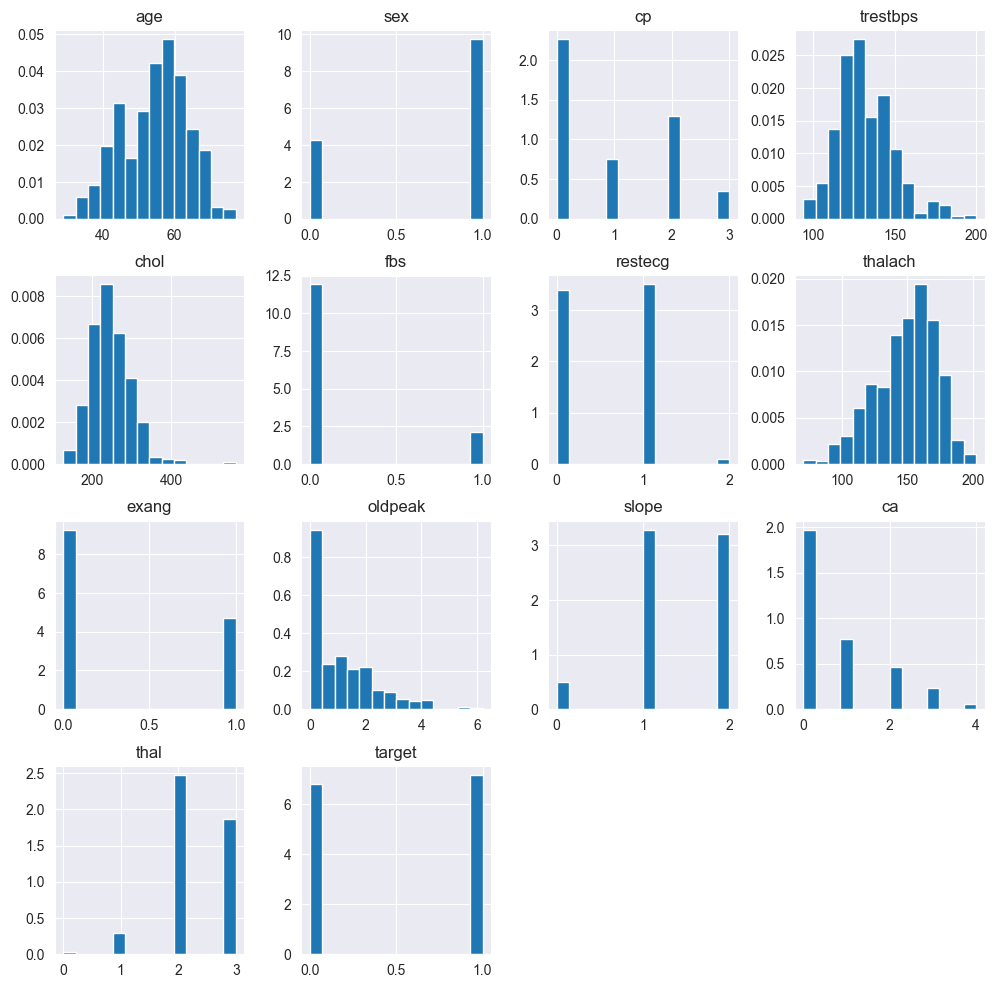

In [37]:
# A General overview of the dataset

data.hist(bins=14, figsize=(12,12),density=True)
plt.show()

### Unique Values

In [38]:
# Distinct values dictionary to map column names to unique values
# This can help with encoding downstream. For example, no need to one-hot encode binary nominal features 

{column: len(data[column].unique())for column in data.columns}

{'age': 41,
 'sex': 2,
 'cp': 4,
 'trestbps': 49,
 'chol': 152,
 'fbs': 2,
 'restecg': 3,
 'thalach': 91,
 'exang': 2,
 'oldpeak': 40,
 'slope': 3,
 'ca': 5,
 'thal': 4,
 'target': 2}

# Feature selection

### Split dataset

In [39]:
 # Split df into X and y
y = data['target'].copy()
X = data.drop('target', axis=1).copy()

In [40]:
columns = X.columns
print('X shape',X.shape)


X shape (1025, 13)


In [41]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 1025, dtype: int64

### Univariate Selection

The following example uses the chi-squared (chi2) statistical test for non-negative features to select the best features from the Dataset.

In [42]:
# Variable selection

data = data.copy()
X = data.iloc[:,0:13]  # columns
y = data.iloc[:,-1]    # target

# SelectKBest class to extract top best features
bestfeatures = SelectKBest(score_func = chi2, k = 10)
fit = bestfeatures.fit(X,y)
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)

# Concat dataframes 
featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Features','Score'] 
print(featureScores.nlargest(13,'Score')) 

    Features       Score
7    thalach  650.008493
9    oldpeak  253.653461
2         cp  217.823922
11        ca  210.625919
8      exang  130.470927
4       chol  110.723364
0        age   81.425368
3   trestbps   45.974069
10     slope   33.673948
1        sex   24.373650
12      thal   19.373465
6    restecg    9.739343
5        fbs    1.477550


### Tree based importances

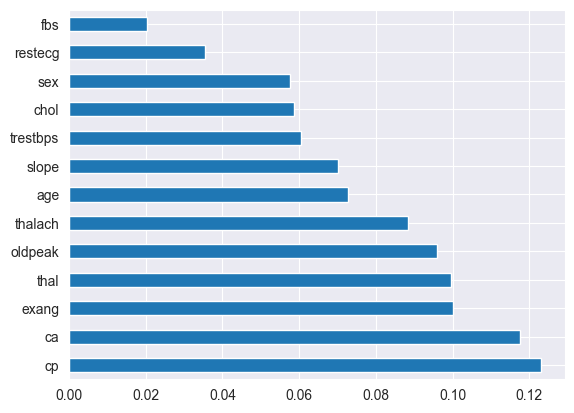

In [43]:
# Extra trees classifier of feature importances

model = ExtraTreesClassifier()
model.fit(X,y)
#print(model.feature_importances_)


feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(13).plot(kind='barh')
plt.show()

## Low varience filtering

Varience

age           82.306450
sex            0.211944
cp             1.060160
trestbps     306.835410
chol        2661.787109
fbs            0.127111
restecg        0.278655
thalach      529.263325
exang          0.223514
oldpeak        1.380750
slope          0.381622
ca             1.062544
thal           0.385219
dtype: float64



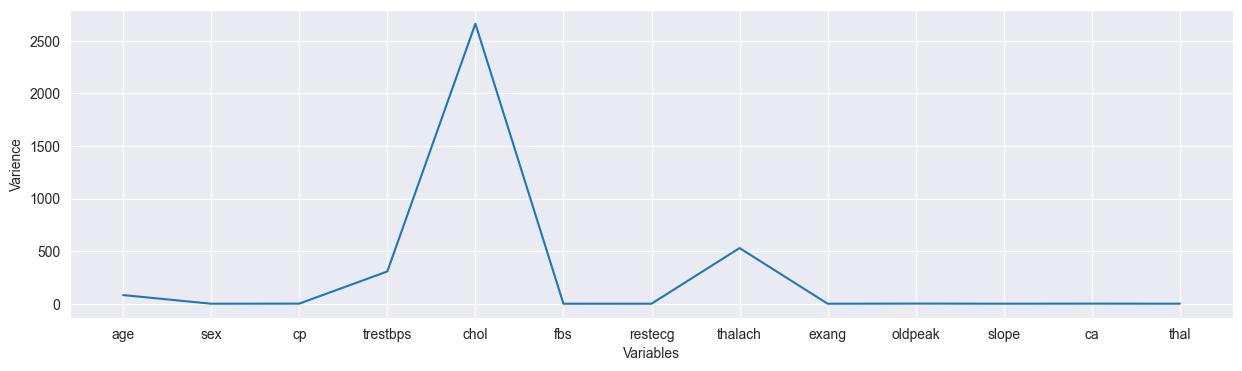

In [44]:
# Dataset variences

variance = X.var()

print('Varience')
print()
print(X.var())

print()

plt.figure(figsize= (15,4))
plt.xlabel('Variables')
plt.ylabel('Varience')
plt.plot(variance)

###  Variables with variance more than the threshold value

In [45]:
# Save variables having variance more than the threshold value
# In this case all original variable are retained

variable = [ ]

for i in range(0,len(variance)):
    if variance[i]>=0.006: #setting the threshold
        variable.append(columns[i])
        
variable

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal']

### New dataframe using the above variables

In [46]:
# creating a new dataframe using the above variables

new_data = X[variable]
print('new_data shape',new_data.shape)
new_data.head()

new_data shape (1025, 13)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2


age           82.306450
sex            0.211944
cp             1.060160
trestbps     306.835410
chol        2661.787109
fbs            0.127111
restecg        0.278655
thalach      529.263325
exang          0.223514
oldpeak        1.380750
slope          0.381622
ca             1.062544
thal           0.385219
dtype: float64



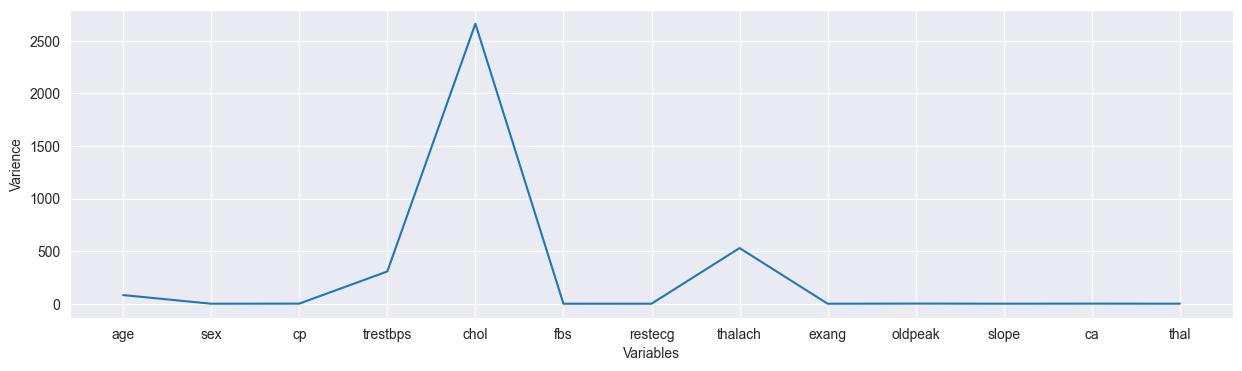

In [47]:
# Data variences

new_data_var = new_data.var()
print(new_data_var)

print()

plt.figure(figsize= (15,4))
plt.xlabel('Variables')
plt.ylabel('Varience')
plt.plot(new_data_var)

No change from original dataset with selected threshold

## Variable Encoding

In [48]:
# One Hot Encoding
# Used for smaller dataset

def onehot_encode(X, column_dict):
    X = new_data.copy()
    for column, prefix in column_dict.items():
        dummies = pd.get_dummies(X[column], prefix=prefix)
        X = pd.concat([X, dummies], axis=1)
        X = X.drop(column, axis=1)
        
    return X


# Encoding

def preprocess_inputs(X): #, scaler
    X = new_data.copy()
    
    # One-hot encode the nominal features
    
    nominal_features = ['cp', 'slope', 'thal','restecg']
    X = onehot_encode(X, dict(zip(nominal_features, ['CP', 'SL', 'TH','RECG'])))
    
       
    return X

In [49]:
# Check Encoded feature 

X = preprocess_inputs(new_data)
print(X.shape)
X

(1025, 23)


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,CP_0,...,SL_0,SL_1,SL_2,TH_0,TH_1,TH_2,TH_3,RECG_0,RECG_1,RECG_2
0,52,1,125,212,0,168,0,1.0,2,True,...,False,False,True,False,False,False,True,False,True,False
1,53,1,140,203,1,155,1,3.1,0,True,...,True,False,False,False,False,False,True,True,False,False
2,70,1,145,174,0,125,1,2.6,0,True,...,True,False,False,False,False,False,True,False,True,False
3,61,1,148,203,0,161,0,0.0,1,True,...,False,False,True,False,False,False,True,False,True,False
4,62,0,138,294,1,106,0,1.9,3,True,...,False,True,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,140,221,0,164,1,0.0,0,False,...,False,False,True,False,False,True,False,False,True,False
1021,60,1,125,258,0,141,1,2.8,1,True,...,False,True,False,False,False,False,True,True,False,False
1022,47,1,110,275,0,118,1,1.0,1,True,...,False,True,False,False,False,True,False,True,False,False
1023,50,0,110,254,0,159,0,0.0,0,True,...,False,False,True,False,False,True,False,True,False,False


In [50]:
y.shape

(1025,)

### Class distributions

In [51]:
#Class distributions

# label encode the target variable
y = LabelEncoder().fit_transform(y)

# summarize distribution
counter = Counter(y)
for k,v in counter.items():
    per = v / len(y) * 100
    print('Class=%d, n=%d (%.3f%%)' % (k, v, per))

Class=0, n=499 (48.683%)
Class=1, n=526 (51.317%)


### Synthetic Minority Oversampling Technique
Optional: classes are fairly well distributed

# Neural Network Definition and Training

In [52]:
# For class label mapping

class_label = {
    0: 'No Heart Disease',
    1: 'Heart Disease'
}

### Train Test Split

In [53]:
# Using 80% for training and 20% for testing

X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=42)

print('X_train shape:',X_train.shape)
print('X_test shape:',X_test.shape)
print('y_test shape:',y_test.shape)
print('y_train shape:',y_train.shape)
print()

n_cols=X_train.shape[1]
print('Columns ',n_cols)

X_train shape: (820, 23)
X_test shape: (205, 23)
y_test shape: (205,)
y_train shape: (820,)

Columns  23


### Scaling

In [54]:
# Scaling options: StandardScaler, MinMaxScaler, RobustScaler

#scaler = StandardScaler()
scaler = MinMaxScaler()
#scaler = RobustScaler()



# Fit on training set only.
scaler.fit(X_train)

# Apply transform to both the training set and the test set.
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [55]:
X_train = np.asarray(X_train,dtype=np.float32)
y_train = np.asarray(y_train,dtype=np.float32)
X_test = np.asarray(X_test,dtype=np.float32)
y_test = np.asarray(y_test,dtype=np.float32)

### Baseline Model Definition

In [56]:
# Remove previous baseline checkpoints if run before

for file_path in [BASELINE_BEST_ACC_WEIGHTS, BASELINE_BEST_LOSS_WEIGHTS]:
    safe_unlink(file_path)

In [57]:
# Baseline NN

require_tensorflow()

# Test on Batch Gradient Descent: batch_size=len(X_train)
# Stochastic Gradient Descent: batch_size=1
# Test mini-batch use batch_size = 256

batch_size = 256
num_classes = 2
epochs = 500
es = EarlyStopping(monitor='val_loss', mode='auto', patience=20, restore_best_weights=True,
 verbose=1)
cpt = ModelCheckpoint(filepath=str(BASELINE_BEST_LOSS_WEIGHTS), monitor='val_loss',
                      verbose=1, save_best_only=True, save_weights_only=True, mode='min')
cpt2 = ModelCheckpoint(filepath=str(BASELINE_BEST_ACC_WEIGHTS), monitor='val_accuracy',
                      verbose=1, save_best_only=True, save_weights_only=True, mode='max')

lr_red = ReduceLROnPlateau(monitor='val_loss', factor=0.01, patience=100)

#lr_schedule = keras.optimizers.schedules.ExponentialDecay(
#    initial_learning_rate=1e-2,
#    decay_steps=10000,
#    decay_rate=0.9)
#optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

def create_baseline():
    # Create model
    model = Sequential()
    model.add(Dense(72, input_dim=(n_cols), activation='relu'))
    model.add(Dense(2, activation='softmax'))#sigmoid

    # Compile model
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])#binary_crossentropy
    return model

model = create_baseline()
model.summary()

Fallback Sequential model backed by sklearn.neural_network.MLPClassifier
Hidden layers: (72,)


In [58]:
# evaluate model with standardized dataset
estimator = make_keras_classifier(create_baseline, epochs=epochs, batch_size=batch_size, verbose=1)
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = cross_val_score(estimator, X_train, y_train, cv=kfold, n_jobs=1)

In [59]:
print("Baseline Model: %.2f%% (%.2f%%)" % (results.mean()*100, results.std()*100))

Baseline Model: 91.34% (3.51%)


### Model fitting

In [60]:
# Fit model

history = model.fit(X_train,
                    y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    callbacks=[cpt,cpt2,lr_red],#[es]cpt,cpt2,
                    verbose=2,
                    validation_split=0.2 ) 

## Models from saved weights

###  To remove any saved models if run before

Saved baseline models are removed safely in the next code cell from `MODEL_DIR` only.

In [61]:
# Removing previous baseline models if run before

for pattern in ['HeartDis_bestLossSNN_*', 'HeartDis_bestAccSNN_*']:
    for file_path in MODEL_DIR.glob(pattern):
        safe_unlink(file_path)

### Save best loss model

In [62]:
# Monitoring loss

model.load_weights(str(BASELINE_BEST_LOSS_WEIGHTS))
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

score = model.evaluate(X_test, y_test, verbose=0)
baseline_loss_model_path = MODEL_DIR / f"HeartDis_bestLossSNN_model.{score[1]:.6f}.keras"
model.save(str(baseline_loss_model_path))

print('Created model and loaded weights from file')
print('Saved model:', baseline_loss_model_path)
print()
print("%s: %.2f%%" % ('Test Accuracy', score[1] * 100))

Created model and loaded weights from file
Saved model: C:\Users\mahmu\OneDrive\Documents\New project\artifacts\notebook\models\HeartDis_bestLossSNN_model.0.863415.keras

Test Accuracy: 86.34%


### Display best loss model

In [63]:
list_files(MODEL_DIR, 'HeartDis_bestLossSNN_*')

,file,path,size_bytes
0,HeartDis_bestLossSNN_model.0.863415.keras,C:\Users\mahmu\OneDrive\Documents\New project\...,40065


### Call loss model

In [64]:
# Load the model

require_tensorflow()
baseline_loss_model_path = latest_file(MODEL_DIR, 'HeartDis_bestLossSNN_model.*.keras')
NewHeart_model = keras.models.load_model(str(baseline_loss_model_path))

NewHeart_model.summary()

Fallback Sequential model backed by sklearn.neural_network.MLPClassifier
Hidden layers: (72,)


### Save best accuracy model

In [65]:
# Monitoring accuracy

model.load_weights(str(BASELINE_BEST_ACC_WEIGHTS))
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

score = model.evaluate(X_test, y_test, verbose=0)
baseline_acc_model_path = MODEL_DIR / f"HeartDis_bestAccSNN_model.{score[1]:.6f}.keras"
model.save(str(baseline_acc_model_path))

print('Created model and loaded weights from file')
print('Saved model:', baseline_acc_model_path)
print()
print("%s: %.2f%%" % ('Test Accuracy', score[1] * 100))

Created model and loaded weights from file
Saved model: C:\Users\mahmu\OneDrive\Documents\New project\artifacts\notebook\models\HeartDis_bestAccSNN_model.0.863415.keras

Test Accuracy: 86.34%


### Display best accuracy model

In [66]:
list_files(MODEL_DIR, 'HeartDis_bestAccSNN_*')

,file,path,size_bytes
0,HeartDis_bestAccSNN_model.0.863415.keras,C:\Users\mahmu\OneDrive\Documents\New project\...,40065


### Call accuracy model

In [67]:
# Load the model

require_tensorflow()
baseline_acc_model_path = latest_file(MODEL_DIR, 'HeartDis_bestAccSNN_model.*.keras')
NewHeart2_model = keras.models.load_model(str(baseline_acc_model_path))

NewHeart2_model.summary()

Fallback Sequential model backed by sklearn.neural_network.MLPClassifier
Hidden layers: (72,)


### Model fitting summary

Loss

In [68]:
# Model fitting summary Loss

score = model.evaluate(X_test, y_test, verbose=0)    
prediction_bl = predict_classes(model, X_test)  #or np.argmax(model.predict(X_test), axis=-1)
prediction_bl2 = predict_classes(model, X_train)

print(model.summary())
print()

# Matthews correlation coefficinet

bl_mcc_test = matthews_corrcoef(y_test,prediction_bl)
print('Matthews correlation coefficient on test:',round(float(bl_mcc_test), 3))
print()

print('train samples:', X_train.shape[0])
print('test samples:', X_test.shape[0])
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Fallback Sequential model backed by sklearn.neural_network.MLPClassifier
Hidden layers: (72,)
None

Matthews correlation coefficient on test: 0.729

train samples: 820
test samples: 205
Test loss: 0.3010860244838286
Test accuracy: 0.8634146341463415


### Model fitting summary

Accuracy

In [69]:
# Model fitting summary Accuracy

score = model.evaluate(X_test, y_test, verbose=0)    
prediction_bl = predict_classes(model, X_test)
prediction_bl2 = predict_classes(model, X_train)

print(model.summary())
print()

# Matthews correlation coefficinet

bl_mcc_test = matthews_corrcoef(y_test,prediction_bl)
print('Matthews correlation coefficient on test:',round(float(bl_mcc_test), 3))
print()

print('train samples:', X_train.shape[0])
print('test samples:', X_test.shape[0])
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Fallback Sequential model backed by sklearn.neural_network.MLPClassifier
Hidden layers: (72,)
None

Matthews correlation coefficient on test: 0.729

train samples: 820
test samples: 205
Test loss: 0.3010860244838286
Test accuracy: 0.8634146341463415


### Classification report

In [70]:
print(classification_report(y_test.astype(int), prediction_bl))

              precision    recall  f1-score   support

           0       0.89      0.82      0.86       102
           1       0.84      0.90      0.87       103

    accuracy                           0.86       205
   macro avg       0.87      0.86      0.86       205
weighted avg       0.87      0.86      0.86       205



### Confusion matrix

Text(0.5, 23.52222222222222, 'Predicted Class')

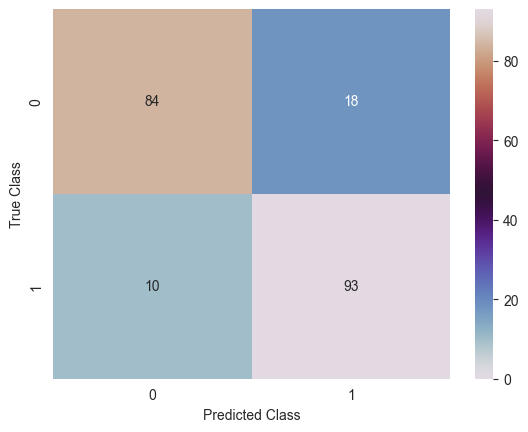

In [71]:
cm = confusion_matrix(y_test,prediction_bl)
#plt.figure(figsize=(10, 10))
sns.heatmap(cm,annot=True, fmt='g', vmin=0, cbar=True, cmap='twilight')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')

### Performanc metrics from the confusion matrix

In [72]:
#Performance metrics from confusion matrix

class_label = globals().get('class_label', {0: 'No Heart Disease', 1: 'Heart Disease'})

FP = cm.sum(axis=0) - np.diag(cm)
FN = cm.sum(axis=1) - np.diag(cm)
TP = np.diag(cm)
TN = cm.sum() - (FP + FN + TP)

FP = FP.astype(float)
FN = FN.astype(float)
TP = TP.astype(float)
TN = TN.astype(float)

# Sensitivity, hit rate, Recall, or true positive rate
TPR = np.divide(TP, TP + FN, out=np.zeros_like(TP), where=(TP + FN) != 0)

# Specificity or true negative rate
TNR = np.divide(TN, TN + FP, out=np.zeros_like(TN), where=(TN + FP) != 0)

# Precision or positive predictive value
PPV = np.divide(TP, TP + FP, out=np.zeros_like(TP), where=(TP + FP) != 0)

# Negative predictive value
NPV = np.divide(TN, TN + FN, out=np.zeros_like(TN), where=(TN + FN) != 0)

# Fall out or false positive rate
FPR = np.divide(FP, FP + TN, out=np.zeros_like(FP), where=(FP + TN) != 0)

# False negative rate
FNR = np.divide(FN, TP + FN, out=np.zeros_like(FN), where=(TP + FN) != 0)

# False discovery rate
FDR = np.divide(FP, TP + FP, out=np.zeros_like(FP), where=(TP + FP) != 0)

print('Class:', class_label)
print('Specificity:', TNR)
print('Specificity Mean:', TNR.mean())
print()
print('Class:', class_label)
print('Recall/Sensitivity:', TPR)
print('Recall/Sensitivity Mean:', TPR.mean())
print()
print('Class:', class_label)
print('Precision:', PPV)
print('Precision Mean:', PPV.mean())
print()
print('Class:', class_label)
print('False Positive Rate:', FPR)
print('False Positive Rate Mean:', FPR.mean())
print()
print('Class:', class_label)
print('False Negative Rate:', FNR)
print('False Negative Rate Mean:', FNR.mean())
print()
print('Class:', class_label)
print('False Discovery Rate:', FDR)
print('False Discovery Rate Mean:', FDR.mean())

Class: {0: 'No Heart Disease', 1: 'Heart Disease'}
Specificity: [0.90291262 0.82352941]
Specificity Mean: 0.8632210165619646

Class: {0: 'No Heart Disease', 1: 'Heart Disease'}
Recall/Sensitivity: [0.82352941 0.90291262]
Recall/Sensitivity Mean: 0.8632210165619646

Class: {0: 'No Heart Disease', 1: 'Heart Disease'}
Precision: [0.89361702 0.83783784]
Precision Mean: 0.8657274295572168

Class: {0: 'No Heart Disease', 1: 'Heart Disease'}
False Positive Rate: [0.09708738 0.17647059]
False Positive Rate Mean: 0.1367789834380354

Class: {0: 'No Heart Disease', 1: 'Heart Disease'}
False Negative Rate: [0.17647059 0.09708738]
False Negative Rate Mean: 0.1367789834380354

Class: {0: 'No Heart Disease', 1: 'Heart Disease'}
False Discovery Rate: [0.10638298 0.16216216]
False Discovery Rate Mean: 0.1342725704427832


### Training and Testing Histories

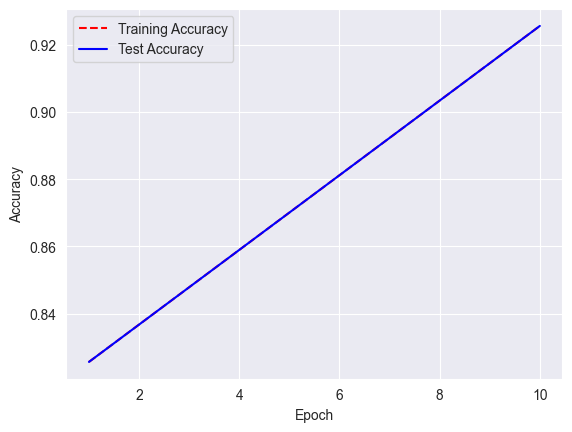

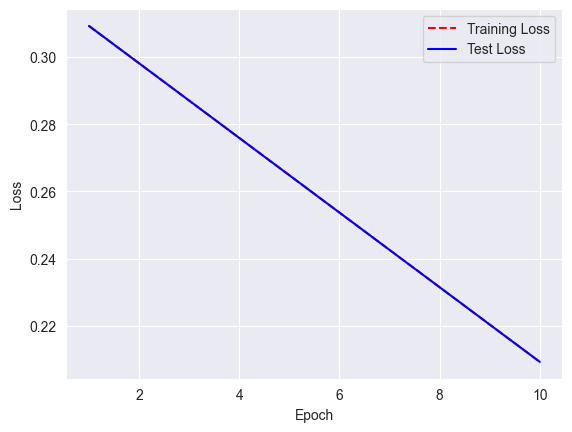

In [73]:
#Get training and test accuracy histories
training_accuracy = history.history['accuracy']
test_accuracy = history.history['val_accuracy']

#Epoch count
epoch_count = range(1,len(training_accuracy) + 1)

#plt.figure(figsize=(8, 6))
plt.plot(epoch_count, training_accuracy, "r--")
plt.plot(epoch_count,test_accuracy, "b-")
plt.legend(['Training Accuracy','Test Accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

#Get training and test loss histories
training_loss = history.history['loss']
test_loss = history.history['val_loss']


#Epoch count
epoch_count = range(1,len(training_loss) + 1)

#Visualize loss history
#plt.figure(figsize=(8, 6))
plt.plot(epoch_count, training_loss, "r--")
plt.plot(epoch_count,test_loss, "b-")
plt.legend(['Training Loss','Test Loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

### ROC - AUC Plot and Score


Heart Disease: ROC-AUC Score: = 0.944



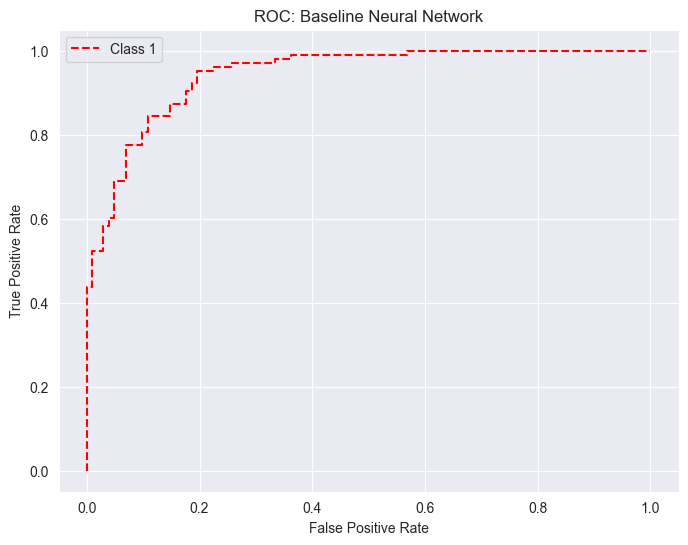

In [74]:
#ROC Plot
#from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

prediction_cplx = predict_proba(model, X_test)

# roc curve for classes
fpr = {}
tpr = {}
thresh ={}

n_class = 2

for i in range(n_class):    
    fpr[i], tpr[i], thresh[i] = roc_curve(y_test, prediction_cplx[:,-1], pos_label=i)

#y_score = classifier.fit(X_train, y_train).decision_function(X_test)
#See machinelearningmastery
# Compute micro-average ROC curve and ROC area
#fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_score.ravel())
#roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])  
ns_probs=[0 for _ in range(len(y_test))]
lr_probs = predict_proba(model, X_test)
lr_probs=lr_probs[:,-1]
ns_auc=roc_auc_score(y_test,ns_probs)
lr_auc=roc_auc_score(y_test,lr_probs)
#print('No Heart Disease:ROC AUC=%.3f'%(ns_auc))
print()
print('Heart Disease: ROC-AUC Score: = %.3f'%(lr_auc))
print()
    
# plotting
plt.figure(figsize=(8, 6))
#plt.plot(fpr[0], tpr[0], linestyle='--',color='steelblue', label='Class 0')
plt.plot(fpr[1], tpr[1], linestyle='--',color='red', label='Class 1')
#plt.plot(fpr[2], tpr[2], linestyle='--',color='blue', label='Class 2 vs Rest')
#plt.plot(fpr[3], tpr[3], linestyle='--',color='red', label='Class 3 vs Rest')
#plt.plot(fpr[4], tpr[4], linestyle='--',color='black', label='Class 4 vs Rest')
#plt.plot(fpr[5], tpr[5], linestyle='--',color='purple', label='Class 5 vs Rest')
#plt.plot(fpr[6], tpr[6], linestyle='--',color='yellow', label='Class 6 vs Rest')
plt.title('ROC: Baseline Neural Network')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='best')
# plt.savefig(FIGURE_DIR / 'baseline_roc.png', dpi=300)

## Predictions and Confidences
 ### Classes and Probabilities

In [75]:
# Classes and Probabilities

prediction_probability = predict_proba(model, X_test)
prediction_cplx = predict_classes(model, X_test)

class_df = pd.DataFrame(prediction_cplx.round(3),columns=['Predicted class'])
proba_df = pd.DataFrame(prediction_probability.round(3),columns=['No heart disease','Heart disease'])

#pred_list = pd.concat(['frame','target_rs'],axis= 1)


predictions_df = pd.concat([proba_df,class_df ], axis=1)
predictions_df.head()

,No heart disease,Heart disease,Predicted class
0,0.019,0.981,1
1,0.172,0.828,1
2,0.994,0.006,0
3,0.005,0.995,1
4,0.972,0.028,0


### Index of  incorrect predictions

In [76]:
# Incorrect predictions

incorrects = np.nonzero(prediction_cplx.reshape((-1,)) != y_test)
incorrects

(array([ 15,  22,  29,  42,  43,  49,  52,  58,  61,  63,  77,  78,  89,
        102, 110, 124, 143, 156, 160, 164, 165, 178, 183, 187, 191, 193,
        195, 196]),)

### Jaccard similarity coefficient

In [77]:
# Jaccard similarity coefficient
# Predicted class compared with actual class

jaccard = jaccard_score(y_test, prediction_cplx, average = None)#prediction_probability

jaccard_df = pd.DataFrame(jaccard,columns=['Jaccard score'])
jaccard_df

,Jaccard score
0,0.750000
1,0.768595


## Confidence interval

The confidence interval is a likelihood over a range. The true model skill may lie outside of this range.
 
**Commonly used number of standard deviations from the Gaussian distribution and their corresponding significance level are as follows:**

* 1.64 (90%)
* 1.96 (95%)
* 2.33 (98%)
* 2.58 (99%)

### Using model error

In [78]:
# 95% confidence interval
# Calculated radius of the confidence interval using model error

# where: interval = z * sqrt( (error * (1 - error)) / n)

interval = 1.96 * sqrt( (0.15 * (1 - .15)) / 61)
print('Classification error interval: %.3f' % interval)

Classification error interval: 0.090


* The classification error of the model is 15% +/- 9%
* The true classification error of the model on unseen data is likely between 6% and 24%.
 
 **The true model skill may lie outside of this range.**

### Upper and lower bounds of model classification accuracy

In [79]:
# Upper and lower bounds of model accuracy

# 218 correct predictions of 238 instances and with 95% confidence interval,
# (provided to the function as a significance of 0.05)

lower, upper = proportion_confint(52, 61, 0.05)

print('Lower Bounds of Accuracy:%.3f ' % lower)
print('Upper Bounds of Accuracy:%.3f ' %upper)

Lower Bounds of Accuracy:0.743 
Upper Bounds of Accuracy:0.920 


 **The true classification accuracy of the model on unseen data is likely between 72% and 92%**.

 **True model skill may lie outside of this range.**

# Increase in Neural Network Size

In [80]:
# Remove previous complex-model checkpoints if run before

for file_path in [COMPLEX_BEST_ACC_WEIGHTS, COMPLEX_BEST_LOSS_WEIGHTS]:
    safe_unlink(file_path)

In [81]:
# Increase in model complexity

require_tensorflow()

batch_size = 256
num_classes = 2
epochs = 500 #175
es = EarlyStopping(monitor='val_loss', mode='auto', patience=20, restore_best_weights=True,
 verbose=1)
cpt = ModelCheckpoint(filepath=str(COMPLEX_BEST_LOSS_WEIGHTS), monitor='val_loss',
                      verbose=1, save_best_only=True, save_weights_only=True, mode='min')
#cpt = ModelCheckpoint(filepath=str(COMPLEX_BEST_ACC_WEIGHTS), monitor='val_accuracy',
#                      verbose=1, save_best_only=True, save_weights_only=True, mode='max')

#lr_schedule = keras.optimizers.schedules.ExponentialDecay(
#    initial_learning_rate=1e-2,
#    decay_steps=10000,
#    decay_rate=0.9)
#optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

def create_cplx():
    # Create model
    model = Sequential()
    model.add(Dense(72, input_dim=(n_cols), kernel_regularizer=regularizers.l1_l2(l1=0.002, l2=0.002), activation='relu'))
    model.add(Dense(64, kernel_regularizer=regularizers.l1_l2(l1=0.002, l2=0.002), activation='relu'))
    model.add(Dense(24, kernel_regularizer=regularizers.l1_l2(l1=0.002, l2=0.002), activation='relu'))
    #model.add(Dense(24, kernel_regularizer=regularizers.l1_l2(l1=0.002, l2=0.002), activation='relu'))
    #model.add(Dense(24, activation='relu'))
    #model.add(Dropout(0.20))
    model.add(Dense(2, activation='softmax'))#sigmoid

    # Compile model
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])#binary_crossentropy
    return model

model = create_cplx()
model.summary()

Fallback Sequential model backed by sklearn.neural_network.MLPClassifier
Hidden layers: (72, 64, 24)


### Cross validation

In [82]:
# evaluate model with standardized dataset
estimator = make_keras_classifier(create_cplx, epochs=epochs, batch_size=batch_size, verbose=1)
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = cross_val_score(estimator, X_train, y_train, cv=kfold, n_jobs=1)

In [83]:
print("Larger Model: %.2f%% (%.2f%%)" % (results.mean()*100, results.std()*100))

Larger Model: 99.15% (1.10%)


### Model fitting

In [84]:
# Fit model

history = model.fit(X_train,
                    y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    callbacks=[cpt],#[es]
                    verbose=2,
                    validation_split=0.2 ) #validation_split=0.2

### Model from saved weights

### Model fitting summary

In [85]:
# Model fitting summary 

score = model.evaluate(X_test, y_test, verbose=0)    
prediction_cplx = predict_classes(model, X_test)
print()


print(model.summary())
print()

# Matthews correlation

mcc_test = matthews_corrcoef(y_test,prediction_cplx)
print('Matthews correlation coefficient on test:',round(float(mcc_test), 3))
print()

print('train samples:', X_train.shape[0])
print('test samples:', X_test.shape[0])
print('Test loss:', score[0])
print('Test accuracy:', score[1])


Fallback Sequential model backed by sklearn.neural_network.MLPClassifier
Hidden layers: (72, 64, 24)
None

Matthews correlation coefficient on test: 0.961

train samples: 820
test samples: 205
Test loss: 0.15838519688865438
Test accuracy: 0.9804878048780488


### Classification report

In [86]:
print(classification_report(y_test.astype(int), prediction_cplx))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       102
           1       0.99      0.97      0.98       103

    accuracy                           0.98       205
   macro avg       0.98      0.98      0.98       205
weighted avg       0.98      0.98      0.98       205



### Confusion matrix

Text(0.5, 23.52222222222222, 'Predicted Class')

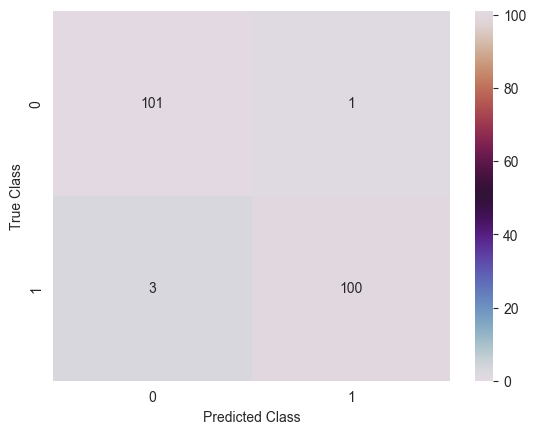

In [87]:
cm = confusion_matrix(y_test,prediction_cplx)
#plt.figure(figsize=(10, 10))
sns.heatmap(cm,annot=True, fmt='g', vmin=0, cbar=True, cmap='twilight')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')

### Performanc metrics from the confusion matrix

In [88]:
#Performance metrics from confusion matrix 

FP = cm.sum(axis=0) - np.diag(cm) 
FN = cm.sum(axis=1) - np.diag(cm)
TP = np.diag(cm)
TN = cm.sum() - (FP + FN + TP)

FP = FP.astype(float)
FN = FN.astype(float)
TP = TP.astype(float)
TN = TN.astype(float)

# Sensitivity, hit rate, Recall, or true positive rate
TPR = TP/(TP+FN)

# Specificity or true negative rate
TNR = TN/(TN+FP) 

# Precision or positive predictive value
PPV = TP/(TP+FP)

# Negative predictive value
NPV = TN/(TN+FN)

# Fall out or false positive rate
FPR = FP/(FP+TN)

# False negative rate
FNR = FN/(TP+FN)

# False discovery rate
FDR = FP/(TP+FP)


print('Class:',class_label)

print('Specificity:',TNR)
print('Specificity Mean:',TNR.mean())

print()

print('Class:',class_label)

print('Recall/Sensitivity:',TPR)
print('Recall/Sensitivity Mean:',TPR.mean())

print()

print('Class:',class_label)

print('Precision:',PPV)
print('Precision Mean:',PPV.mean())

print()

print('Class:',class_label)

print('False Positive Rate:',FPR)
print('False Positive Rate Mean:',FPR.mean())

print()

print('Class:',class_label)

print('False Negative Rate:',FNR)
print('False Negative Rate Mean:',FNR.mean())

print()

print('Class:',class_label)

print('False Discovery Rate:',FDR)
print('False Discovery Rate Mean:',FDR.mean())

Class: {0: 'No Heart Disease', 1: 'Heart Disease'}
Specificity: [0.97087379 0.99019608]
Specificity Mean: 0.9805349324195698

Class: {0: 'No Heart Disease', 1: 'Heart Disease'}
Recall/Sensitivity: [0.99019608 0.97087379]
Recall/Sensitivity Mean: 0.9805349324195698

Class: {0: 'No Heart Disease', 1: 'Heart Disease'}
Precision: [0.97115385 0.99009901]
Precision Mean: 0.9806264280274182

Class: {0: 'No Heart Disease', 1: 'Heart Disease'}
False Positive Rate: [0.02912621 0.00980392]
False Positive Rate Mean: 0.01946506758043023

Class: {0: 'No Heart Disease', 1: 'Heart Disease'}
False Negative Rate: [0.00980392 0.02912621]
False Negative Rate Mean: 0.01946506758043023

Class: {0: 'No Heart Disease', 1: 'Heart Disease'}
False Discovery Rate: [0.02884615 0.00990099]
False Discovery Rate Mean: 0.019373571972581875


### Training and Testing Histories

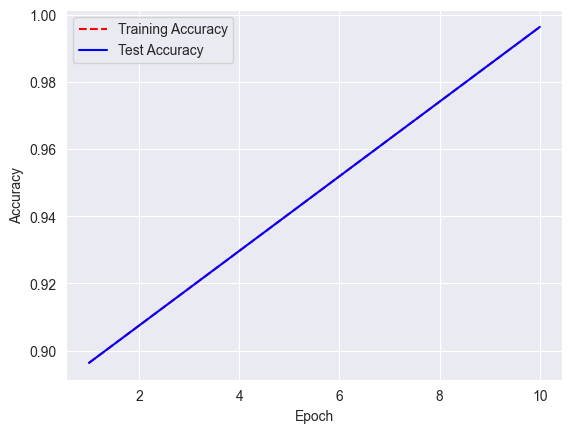

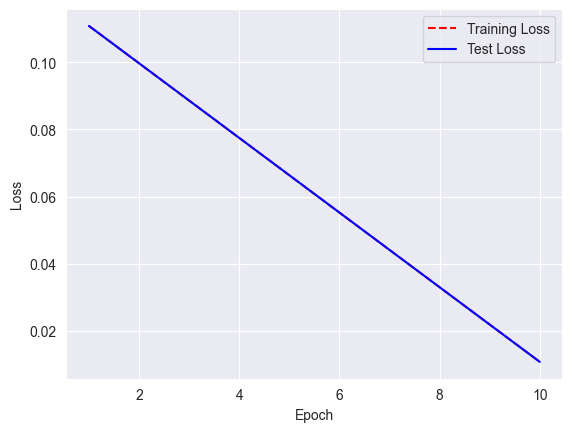

In [89]:
#Get training and test accuracy histories
training_accuracy = history.history['accuracy']
test_accuracy = history.history['val_accuracy']

#Epoch count
epoch_count = range(1,len(training_accuracy) + 1)

#plt.figure(figsize=(8, 6))
plt.plot(epoch_count, training_accuracy, "r--")
plt.plot(epoch_count,test_accuracy, "b-")
plt.legend(['Training Accuracy','Test Accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

#Get training and test loss histories
training_loss = history.history['loss']
test_loss = history.history['val_loss']


#Epoch count
epoch_count = range(1,len(training_loss) + 1)

#Visualize loss history
#plt.figure(figsize=(8, 6))
plt.plot(epoch_count, training_loss, "r--")
plt.plot(epoch_count,test_loss, "b-")
plt.legend(['Training Loss','Test Loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

### ROC - AUC Plot and Score


Heart Disease: ROC-AUC Score: = 0.986



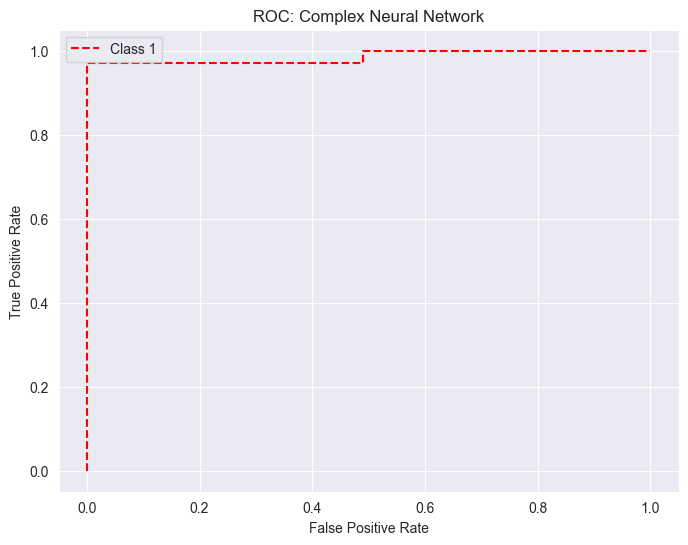

In [90]:
#ROC Plot
#from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

prediction_cplx = predict_proba(model, X_test)

# roc curve for classes
fpr = {}
tpr = {}
thresh ={}

n_class = 2

for i in range(n_class):    
    fpr[i], tpr[i], thresh[i] = roc_curve(y_test, prediction_cplx[:,-1], pos_label=i)

#y_score = classifier.fit(X_train, y_train).decision_function(X_test)
#See machinelearningmastery
# Compute micro-average ROC curve and ROC area
#fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_score.ravel())
#roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])  
ns_probs=[0 for _ in range(len(y_test))]
lr_probs = predict_proba(model, X_test)
lr_probs=lr_probs[:,-1]
ns_auc=roc_auc_score(y_test,ns_probs)
lr_auc=roc_auc_score(y_test,lr_probs)
#print('No Heart Disease:ROC AUC=%.3f'%(ns_auc))
print()
print('Heart Disease: ROC-AUC Score: = %.3f'%(lr_auc))
print()
    
# plotting
plt.figure(figsize=(8, 6))
#plt.plot(fpr[0], tpr[0], linestyle='--',color='steelblue', label='Class 0')
plt.plot(fpr[1], tpr[1], linestyle='--',color='red', label='Class 1')
#plt.plot(fpr[2], tpr[2], linestyle='--',color='blue', label='Class 2 vs Rest')
#plt.plot(fpr[3], tpr[3], linestyle='--',color='red', label='Class 3 vs Rest')
#plt.plot(fpr[4], tpr[4], linestyle='--',color='black', label='Class 4 vs Rest')
#plt.plot(fpr[5], tpr[5], linestyle='--',color='purple', label='Class 5 vs Rest')
#plt.plot(fpr[6], tpr[6], linestyle='--',color='yellow', label='Class 6 vs Rest')
plt.title('ROC: Complex Neural Network')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='best')
# plt.savefig(FIGURE_DIR / 'complex_roc.png', dpi=300)

## Predictions and Confidences
 **Classes and Probabilities**

In [91]:
# Classes and Probabilities

prediction_probability = predict_proba(model, X_test)
prediction_cplx = predict_classes(model, X_test)

class_df = pd.DataFrame(prediction_cplx.round(3),columns=['Predicted class'])
proba_df = pd.DataFrame(prediction_probability.round(3),columns=['No heart disease','Heart disease'])

#pred_list = pd.concat(['frame','target_rs'],axis= 1)


predictions_df = pd.concat([proba_df,class_df ], axis=1)
predictions_df

,No heart disease,Heart disease,Predicted class
0,0.000,1.000,1
1,0.000,1.000,1
2,1.000,0.000,0
3,0.000,1.000,1
4,1.000,0.000,0
...,...,...,...
200,0.002,0.998,1
201,0.000,1.000,1
202,0.012,0.988,1
203,1.000,0.000,0


### Index of  incorrect predictions

In [92]:
# Incorrect predictions

incorrects = np.nonzero(prediction_cplx.reshape((-1,)) != y_test)
incorrects

(array([ 20,  24,  36, 196]),)

### Jaccard similarity coefficient

In [93]:
# Jaccard similarity coefficient
# Predicted class compared with actual class


jaccard = jaccard_score(y_test, prediction_cplx, average = None)

jaccard_df = pd.DataFrame(jaccard,columns=['Jaccard score'])
jaccard_df

,Jaccard score
0,0.961905
1,0.961538


## Confidence interval

The confidence interval is a likelihood over a range. The true model skill may lie outside of this range.
 
**Commonly used number of standard deviations from the Gaussian distribution and their corresponding significance level are as follows:**

* 1.64 (90%)
* 1.96 (95%)
* 2.33 (98%)
* 2.58 (99%)

### Using model error

In [94]:
# 95% confidence interval
# Calculated radius of the confidence interval using model error

# where: interval = z * sqrt( (error * (1 - error)) / n)

interval = 1.96 * sqrt( (0.13 * (1 - .13)) / 61)
print('Classification error interval: %.3f' % interval)

Classification error interval: 0.084


* The classification error of the model is 13% +/- 8%
* The true classification error of the model on unseen data is likely between 5% and 21%.
 
 **The true model skill may lie outside of this range.**


### Upper and lower bounds of model classification accuracy

In [95]:
# Upper and lower bounds of model accuracy

# 218 correct predictions of 238 instances and with 95% confidence interval,
# (provided to the function as a significance of 0.05)

lower, upper = proportion_confint(53, 61, 0.05)

print('Lower Bounds of Accuracy:%.3f ' % lower)
print('Upper Bounds of Accuracy:%.3f ' %upper)

Lower Bounds of Accuracy:0.762 
Upper Bounds of Accuracy:0.932 


 **The true classification accuracy of the model on unseen data is likely between 78% and 95%**.

 **True model skill may lie outside of this range.**

#  2. Model Tuning and Evaluation

### Grid Search
#### Tuning  a neural net model 

Searching through activation functions and optimizers comparing the results with the best peforming model from the model definition and training phase.


**________________________________________________________________________________________________________**

**Use code below to remove saved models if run before.**

**Note the saved path to avoid unintentionally deleting valuable models.**

In [96]:
# Remove previous tuned models if run before

for file_path in MODEL_DIR.glob('kerSM_Test_tuned*'):
    safe_unlink(file_path)

#### Parameter grid for tuning neural network

In [97]:
#define parameter grid

require_tensorflow()

batch_size = 256
num_classes = 2 
epochs = 500 #675
es = EarlyStopping(monitor='val_loss', mode='auto', patience=10, restore_best_weights=True,
 verbose=1)

activation_functions_layer_1 = ['selu','relu','elu','tanh'] 
activation_functions_layer_2 = ['selu','relu','elu','tanh']
activation_functions_layer_3 = ['selu','relu','elu','tanh']
opimizers = ['RMSprop','adam','nadam','sgd']

#optimize over parameter grid (grid search)

for activation_function_layer_1 in activation_functions_layer_1:
    for activation_function_layer_2 in activation_functions_layer_2:
        for activation_function_layer_3 in activation_functions_layer_3:
            for opimizer in opimizers:
                
    
        
            
                model = Sequential()
                model.add(Dense(72,kernel_regularizer=regularizers.l1_l2(l1=0.002, l2=0.002), activation = activation_function_layer_1, input_shape=(n_cols,)))               
                model.add(Dense(64,kernel_regularizer=regularizers.l1_l2(l1=0.002, l2=0.002), activation=activation_function_layer_2))
                model.add(Dense(24,kernel_regularizer=regularizers.l1_l2(l1=0.002, l2=0.002), activation=activation_function_layer_3))
                #model.add(Dropout(0.20))
                model.add(Dense(num_classes, activation='softmax'))
            
            
                model.compile(loss='sparse_categorical_crossentropy',
                              optimizer=opimizer,
                              metrics=['accuracy'])

                history = model.fit(X_train, y_train, 
                batch_size=batch_size,
                epochs=epochs,
                callbacks=[es],        
                verbose=1,
                validation_data=(X_test, y_test))
        
                score = model.evaluate(X_test, y_test, verbose=0)
                save_path = MODEL_DIR / f"kerSM_Test_tuned_HeartDis_model.{activation_function_layer_1}.{activation_function_layer_2}.{activation_function_layer_3}.{opimizer}.{score[1]:.3f}.keras"

                model.save(str(save_path))

**Saved models**

In [98]:
list_files(MODEL_DIR, 'kerSM_Test_tuned_*')

,file,path,size_bytes
0,kerSM_Test_tuned_HeartDis_model.elu.elu.elu.ad...,C:\Users\mahmu\OneDrive\Documents\New project\...,139589
1,kerSM_Test_tuned_HeartDis_model.elu.elu.elu.na...,C:\Users\mahmu\OneDrive\Documents\New project\...,139589
2,kerSM_Test_tuned_HeartDis_model.elu.elu.elu.RM...,C:\Users\mahmu\OneDrive\Documents\New project\...,139589
3,kerSM_Test_tuned_HeartDis_model.elu.elu.elu.sg...,C:\Users\mahmu\OneDrive\Documents\New project\...,139589
4,kerSM_Test_tuned_HeartDis_model.elu.elu.relu.a...,C:\Users\mahmu\OneDrive\Documents\New project\...,139589
...,...,...,...
251,kerSM_Test_tuned_HeartDis_model.tanh.tanh.selu...,C:\Users\mahmu\OneDrive\Documents\New project\...,139590
252,kerSM_Test_tuned_HeartDis_model.tanh.tanh.tanh...,C:\Users\mahmu\OneDrive\Documents\New project\...,139585
253,kerSM_Test_tuned_HeartDis_model.tanh.tanh.tanh...,C:\Users\mahmu\OneDrive\Documents\New project\...,139585
254,kerSM_Test_tuned_HeartDis_model.tanh.tanh.tanh...,C:\Users\mahmu\OneDrive\Documents\New project\...,139585


### Load and evaluate the best model from grid search

In [99]:
require_tensorflow()
tuned_model_path = latest_file(MODEL_DIR, 'kerSM_Test_tuned_HeartDis_model.*.keras')
tuned_model = keras.models.load_model(str(tuned_model_path))

tuned_model.summary()

Fallback Sequential model backed by sklearn.neural_network.MLPClassifier
Hidden layers: (72, 64, 24)


### Model fitting summary 

In [100]:
# Model fitting summary 
score = tuned_model.evaluate(X_test, y_test, verbose=0)
prediction_cplx = predict_classes(tuned_model, X_test)

print(tuned_model.summary())
print()
mcc_test = matthews_corrcoef(y_test,prediction_cplx)
print('Matthews correlation coefficient on test:',round(float(mcc_test), 3))
print()
print('train samples:', X_train.shape[0])
print('test samples:', X_test.shape[0])
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Fallback Sequential model backed by sklearn.neural_network.MLPClassifier
Hidden layers: (72, 64, 24)
None

Matthews correlation coefficient on test: 0.825

train samples: 820
test samples: 205
Test loss: 0.1853906450763684
Test accuracy: 0.9121951219512195


### Classification report

In [101]:
print(classification_report(y_test.astype(int), prediction_cplx))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91       102
           1       0.90      0.92      0.91       103

    accuracy                           0.91       205
   macro avg       0.91      0.91      0.91       205
weighted avg       0.91      0.91      0.91       205



### Confusion matrix

Text(0.5, 23.52222222222222, 'Predicted Class')

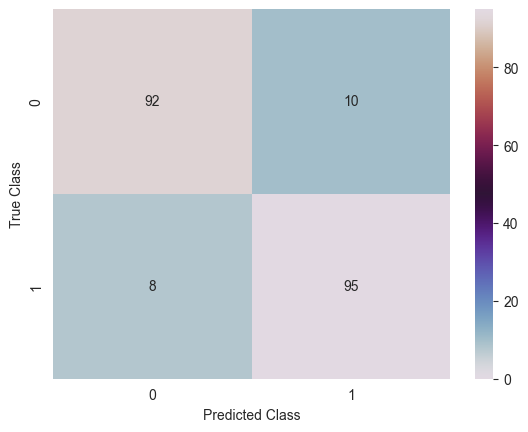

In [102]:
cm = confusion_matrix(y_test,prediction_cplx)
#plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cbar=True, cmap='twilight')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')

### Performance metrics from confusion matrix

In [103]:
#Performance metrics from confusion matrix 

FP = cm.sum(axis=0) - np.diag(cm) 
FN = cm.sum(axis=1) - np.diag(cm)
TP = np.diag(cm)
TN = cm.sum() - (FP + FN + TP)

FP = FP.astype(float)
FN = FN.astype(float)
TP = TP.astype(float)
TN = TN.astype(float)

# Sensitivity, hit rate, Recall, or true positive rate
TPR = TP/(TP+FN)

# Specificity or true negative rate
TNR = TN/(TN+FP) 

# Precision or positive predictive value
PPV = TP/(TP+FP)

# Negative predictive value
NPV = TN/(TN+FN)

# Fall out or false positive rate
FPR = FP/(FP+TN)

# False negative rate
FNR = FN/(TP+FN)

# False discovery rate
FDR = FP/(TP+FP)


print('Class:',class_label)

print('Specificity:',TNR)
print('Specificity Mean:',TNR.mean())

print()

print('Class:',class_label)

print('Recall/Sensitivity:',TPR)
print('Recall/Sensitivity Mean:',TPR.mean())

print()

print('Class:',class_label)

print('Precision:',PPV)
print('Precision Mean:',PPV.mean())

print()

print('Class:',class_label)

print('False Positive Rate:',FPR)
print('False Positive Rate Mean:',FPR.mean())

print()

print('Class:',class_label)

print('False Negative Rate:',FNR)
print('False Negative Rate Mean:',FNR.mean())

print()

print('Class:',class_label)

print('False Discovery Rate:',FDR)
print('False Discovery Rate Mean:',FDR.mean())

Class: {0: 'No Heart Disease', 1: 'Heart Disease'}
Specificity: [0.9223301  0.90196078]
Specificity Mean: 0.912145440700552

Class: {0: 'No Heart Disease', 1: 'Heart Disease'}
Recall/Sensitivity: [0.90196078 0.9223301 ]
Recall/Sensitivity Mean: 0.912145440700552

Class: {0: 'No Heart Disease', 1: 'Heart Disease'}
Precision: [0.92      0.9047619]
Precision Mean: 0.9123809523809524

Class: {0: 'No Heart Disease', 1: 'Heart Disease'}
False Positive Rate: [0.0776699  0.09803922]
False Positive Rate Mean: 0.08785455929944794

Class: {0: 'No Heart Disease', 1: 'Heart Disease'}
False Negative Rate: [0.09803922 0.0776699 ]
False Negative Rate Mean: 0.08785455929944794

Class: {0: 'No Heart Disease', 1: 'Heart Disease'}
False Discovery Rate: [0.08      0.0952381]
False Discovery Rate Mean: 0.08761904761904762


### ROC Score


Heart Disease: ROC-AUC Score: = 0.980



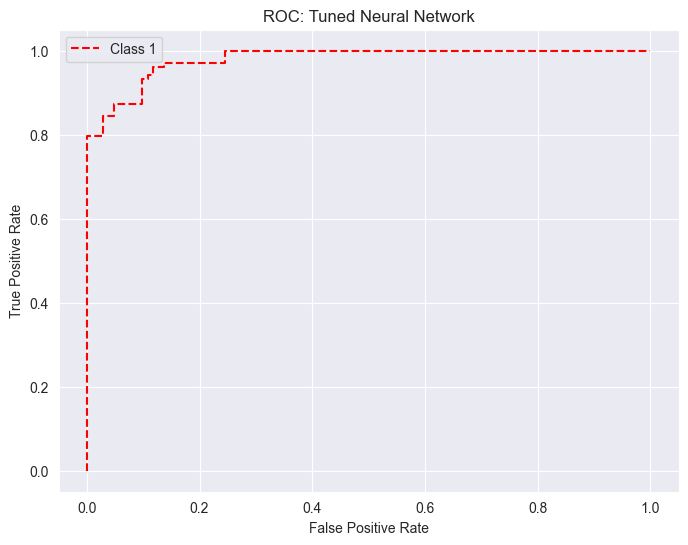

In [104]:
#ROC Plot
#from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

prediction_cplx = predict_proba(tuned_model, X_test)

# roc curve for classes
fpr = {}
tpr = {}
thresh ={}

n_class = 2

for i in range(n_class):    
    fpr[i], tpr[i], thresh[i] = roc_curve(y_test, prediction_cplx[:,-1], pos_label=i)

#y_score = classifier.fit(X_train, y_train).decision_function(X_test)
#See machinelearningmastery
# Compute micro-average ROC curve and ROC area
#fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_score.ravel())
#roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])  
ns_probs=[0 for _ in range(len(y_test))]
lr_probs = predict_proba(tuned_model, X_test)
lr_probs=lr_probs[:,-1]
ns_auc=roc_auc_score(y_test,ns_probs)
lr_auc=roc_auc_score(y_test,lr_probs)
#print('No Heart Disease:ROC AUC=%.3f'%(ns_auc))
print()
print('Heart Disease: ROC-AUC Score: = %.3f'%(lr_auc))
print()
    
# plotting
plt.figure(figsize=(8, 6))
#plt.plot(fpr[0], tpr[0], linestyle='--',color='steelblue', label='Class 0')
plt.plot(fpr[1], tpr[1], linestyle='--',color='red', label='Class 1')
#plt.plot(fpr[2], tpr[2], linestyle='--',color='blue', label='Class 2 vs Rest')
#plt.plot(fpr[3], tpr[3], linestyle='--',color='red', label='Class 3 vs Rest')
#plt.plot(fpr[4], tpr[4], linestyle='--',color='black', label='Class 4 vs Rest')
#plt.plot(fpr[5], tpr[5], linestyle='--',color='purple', label='Class 5 vs Rest')
#plt.plot(fpr[6], tpr[6], linestyle='--',color='yellow', label='Class 6 vs Rest')
plt.title('ROC: Tuned Neural Network')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='best')
# plt.savefig(FIGURE_DIR / 'tuned_roc.png', dpi=300)

## Predictions and Confidences
 **Classes and Probabilities**

In [105]:
# Classes and Probabilities

prediction_probability = predict_proba(tuned_model, X_test)
prediction_cplx = predict_classes(tuned_model, X_test)

class_df = pd.DataFrame(prediction_cplx.round(3),columns=['Predicted class'])
proba_df = pd.DataFrame(prediction_probability.round(3),columns=['No heart disease','Heart disease'])

#pred_list = pd.concat(['frame','target_rs'],axis= 1)


predictions_df = pd.concat([proba_df,class_df ], axis=1)
predictions_df.head()

,No heart disease,Heart disease,Predicted class
0,0.000,1.000,1
1,0.038,0.962,1
2,1.000,0.000,0
3,0.000,1.000,1
4,0.998,0.002,0


### Index of incorrect predictions

In [106]:
# Incorrect predictions

incorrects = np.nonzero(prediction_cplx.reshape((-1,)) != y_test)
incorrects

(array([ 20,  24,  29,  36,  50,  58,  78,  89, 102, 107, 110, 143, 146,
        178, 187, 191, 196, 200]),)

### Jaccard similarity coefficient

In [107]:
# Jaccard similarity coefficient
# Predicted class compared with actual class

jaccard = jaccard_score(y_test, prediction_cplx, average = None)#prediction_probability

jaccard_df = pd.DataFrame(jaccard,columns=['Jaccard score'])
jaccard_df

,Jaccard score
0,0.836364
1,0.840708


### Confidence interval

The confidence interval is a likelihood over a range. The true model skill may lie outside of this range.
 
**Commonly used number of standard deviations from the Gaussian distribution and their corresponding significance level are as follows:**

* 1.64 (90%)
* 1.96 (95%)
* 2.33 (98%)
* 2.58 (99%)

#### Using model error

In [108]:
# 95% confidence interval
# calculated radius of the confidence interval using model error

# where: interval = z * sqrt( (error * (1 - error)) / n)

interval = 1.96 * sqrt( (0.10 * (1 - .10)) / 61)
print('Classification error interval: %.3f' % interval)

Classification error interval: 0.075


* The classification error of the model is 10% +/- 8%
* The true classification error of the model on unseen data is likely between 2% and 18%
 
 **The true model skill may lie outside of this range.**

### Upper and lower bounds of model accuracy

In [109]:
# Upper and lower bounds of model accuracy

# from statsmodels.stats.proportion import proportion_confint

lower, upper = proportion_confint(55, 61, 0.05)

print('Lower Bounds of Accuracy:%.3f ' % lower)
print('Upper Bounds of Accuracy:%.3f ' %upper)

Lower Bounds of Accuracy:0.802 
Upper Bounds of Accuracy:0.954 


* The true classification accuracy of the model on unseen data is likely between 83% and 98%.
 

**True model skill may lie outside of this range**

### Save the new model

In [110]:
tuned_model_path = MODEL_DIR / 'HeartDisSM_tuned.keras'
tuned_model.save(str(tuned_model_path))
print('Saved model:', tuned_model_path)

Saved model: C:\Users\mahmu\OneDrive\Documents\New project\artifacts\notebook\models\HeartDisSM_tuned.keras


In [111]:
# Sanity check

require_tensorflow()
reconstructed_model_path = MODEL_DIR / 'HeartDisSM_tuned.keras'
reconstructed_model = keras.models.load_model(str(reconstructed_model_path))
reconstructed_model.summary()

Fallback Sequential model backed by sklearn.neural_network.MLPClassifier
Hidden layers: (72, 64, 24)


In [112]:
list_files(MODEL_DIR, 'HeartDisSM_*')

,file,path,size_bytes
0,HeartDisSM_tuned.keras,C:\Users\mahmu\OneDrive\Documents\New project\...,139585


# Sample prediction and probabilities

In [113]:
# Sample prediction and probabilities

prediction_probability = predict_proba(reconstructed_model, X_test)
prediction_cplx = predict_classes(reconstructed_model, X_test)

print()
print('The probabilities of the sample are:',prediction_probability[4].round(3))
print()
print('The predicted class of the sample is:', prediction_cplx[4])
print()
print('Index of incorrects:',incorrects)

predictions_df.head()


The probabilities of the sample are: [0.998 0.002]

The predicted class of the sample is: 0

Index of incorrects: (array([ 20,  24,  29,  36,  50,  58,  78,  89, 102, 107, 110, 143, 146,
       178, 187, 191, 196, 200]),)


,No heart disease,Heart disease,Predicted class
0,0.000,1.000,1
1,0.038,0.962,1
2,1.000,0.000,0
3,0.000,1.000,1
4,0.998,0.002,0
